<a href="https://colab.research.google.com/github/Suryasenthi/surya/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = {
    'text': [
        "Free entry in 2 a wkly comp to win FA Cup",
        "Nah I don't think he goes to usf, he lives around here",
        "Win a $1000 Walmart gift card, claim now!",
        "Hey, are we still meeting for lunch today?",
        "Congratulations! You've been selected for a prize",
        "Can you call me later? I am busy now",
        "Get cheap meds online, limited offer",
        "Don't forget to bring the documents"
    ],
    'label': [
        'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham'
    ]
}


In [4]:
import pandas as pd
df = pd.DataFrame(data)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.3, random_state=42)


In [6]:
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

In [7]:
mnb = MultinomialNB()
mnb.fit(X_train_counts, y_train)
y_pred_mnb = mnb.predict(X_test_counts)

In [8]:
print("=== Multinomial Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_mnb))
print(confusion_matrix(y_test, y_pred_mnb))
print(classification_report(y_test, y_pred_mnb))

=== Multinomial Naive Bayes ===
Accuracy: 0.6666666666666666
[[1 1]
 [0 1]]
              precision    recall  f1-score   support

         ham       1.00      0.50      0.67         2
        spam       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [9]:
bnb = BernoulliNB()
bnb.fit(X_train_counts, y_train)
y_pred_bnb = bnb.predict(X_test_counts)

In [10]:
print("=== Bernoulli Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_bnb))
print(confusion_matrix(y_test, y_pred_bnb))
print(classification_report(y_test, y_pred_bnb))

=== Bernoulli Naive Bayes ===
Accuracy: 0.6666666666666666
[[1 1]
 [0 1]]
              precision    recall  f1-score   support

         ham       1.00      0.50      0.67         2
        spam       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [11]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


In [12]:
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)
y_pred_mnb_tfidf = mnb_tfidf.predict(X_test_tfidf)
print("=== Multinomial NB with TF-IDF ===")
print("Accuracy:", accuracy_score(y_test, y_pred_mnb_tfidf))

=== Multinomial NB with TF-IDF ===
Accuracy: 0.6666666666666666


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [14]:
data = {
    'text': [
        "Free entry in 2 a wkly comp to win FA Cup",
        "Nah I don't think he goes to usf, he lives around here",
        "Win a $1000 Walmart gift card, claim now!",
        "Hey, are we still meeting for lunch today?",
        "Congratulations! You've been selected for a prize",
        "Can you call me later? I am busy now",
        "Get cheap meds online, limited offer",
        "Don't forget to bring the documents"
    ],
    'label': [
        'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham'
    ]
}

df = pd.DataFrame(data)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.3, random_state=42)


In [16]:
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)


In [17]:
mnb = MultinomialNB()
mnb.fit(X_train_counts, y_train)
y_pred_mnb = mnb.predict(X_test_counts)

bnb = BernoulliNB()
bnb.fit(X_train_counts, y_train)
y_pred_bnb = bnb.predict(X_test_counts)

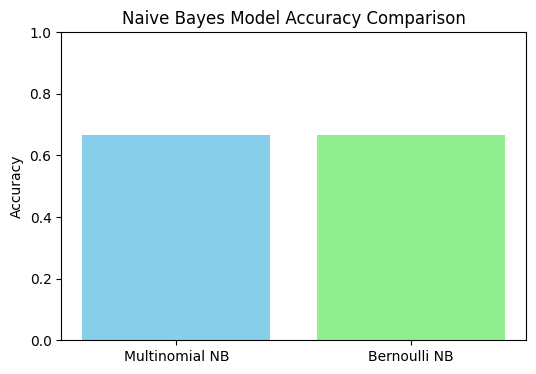

In [18]:
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)

plt.figure(figsize=(6,4))
plt.bar(['Multinomial NB', 'Bernoulli NB'], [accuracy_mnb, accuracy_bnb], color=['skyblue','lightgreen'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Naive Bayes Model Accuracy Comparison")
plt.show()

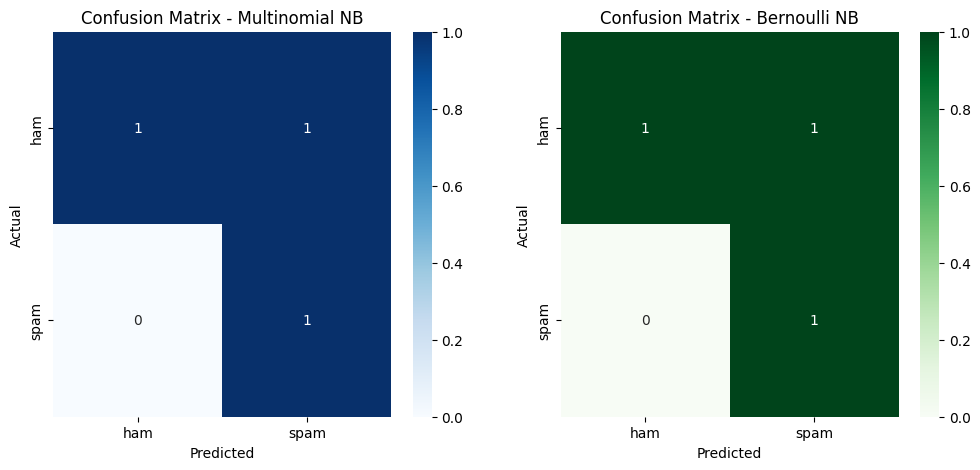

In [19]:
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
cm_bnb = confusion_matrix(y_test, y_pred_bnb)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title("Confusion Matrix - Multinomial NB")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Greens', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title("Confusion Matrix - Bernoulli NB")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
feature_names = vectorizer.get_feature_names_out()
class_labels = mnb.classes_

topn = 5

spam_class_idx = np.where(class_labels == 'spam')[0][0]

spam_feature_log_probs = mnb.feature_log_prob_[spam_class_idx]

spam_features = sorted(zip(spam_feature_log_probs, feature_names), reverse=True)[:topn]

/tmp/ipython-input-3689846630.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef, y=features, palette='Reds_r')


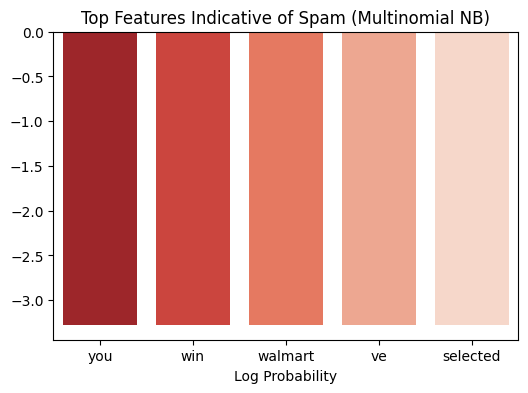

In [23]:
features, coef = zip(*spam_features)
plt.figure(figsize=(6,4))
sns.barplot(x=coef, y=features, palette='Reds_r')
plt.title("Top Features Indicative of Spam (Multinomial NB)")
plt.xlabel("Log Probability")
plt.show()